In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Anchor to project root
os.chdir('/Users/eldigardonaz/Documents/WorldCup-2026-Analytics')
print("Working directory:", os.getcwd())

# Load the model-ready dataset from Phase 3
df = pd.read_csv('data/processed/model_ready.csv')
df['date'] = pd.to_datetime(df['date'])

print("Dataset loaded ✓")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("\nResult distribution:")
print(df['result'].value_counts())

Working directory: /Users/eldigardonaz/Documents/WorldCup-2026-Analytics
Dataset loaded ✓
Rows: 7482
Columns: ['date', 'home_team', 'away_team', 'tournament', 'match_year', 'elo_diff', 'home_elo', 'away_elo', 'home_form_pts', 'away_form_pts', 'form_pts_diff', 'home_form_gf', 'away_form_gf', 'home_form_ga', 'away_form_ga', 'home_is_host', 'away_is_host', 'host_diff', 'is_knockout', 'result']

Result distribution:
result
Home Win    3460
Away Win    2101
Draw        1921
Name: count, dtype: int64


In [2]:
# --- Date-based train/test split (NO random shuffling) ---
# Train on everything before 2018, test on 2018 onward
split_date = '2018-01-01'

train = df[df['date'] < split_date].copy()
test = df[df['date'] >= split_date].copy()

# Define which columns are the model's input features
feature_cols = [
    'elo_diff', 'home_elo', 'away_elo',
    'home_form_pts', 'away_form_pts', 'form_pts_diff',
    'home_form_gf', 'away_form_gf', 'home_form_ga', 'away_form_ga',
    'home_is_host', 'away_is_host', 'host_diff', 'is_knockout'
]

X_train = train[feature_cols]
y_train = train['result']
X_test = test[feature_cols]
y_test = test['result']

print("Train set:", len(X_train), "matches (before 2018)")
print("Test set: ", len(X_test), "matches (2018 onward)")
print("\nTrain date range:", train['date'].min().date(), "→", train['date'].max().date())
print("Test date range: ", test['date'].min().date(), "→", test['date'].max().date())
print("\nTest set result distribution (what we're predicting):")
print(y_test.value_counts())

Train set: 6411 matches (before 2018)
Test set:  1071 matches (2018 onward)

Train date range: 1903-04-04 → 2017-12-26
Test date range:  2018-01-28 → 2026-06-27

Test set result distribution (what we're predicting):
result
Home Win    473
Draw        303
Away Win    295
Name: count, dtype: int64


## (I) Initial Baseline — Logistic Regression

First model attempt using a simple, interpretable linear classifier.

- **Accuracy:** 48.1% (vs 44.2% baseline of always guessing Home Win)
- **Limitation:** Near-zero draw recall (0.01); The model defaults to predicting Home Win on uncertain matches
- **Lesson:** Football outcomes are non-linear; a linear model under-fits. Draws are genuinely hard to predict (confirmed by research — even professional models struggle here).

In [3]:
# --- Train the first model: Logistic Regression ---
# Start simple and interpretable, exactly as planned

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set (matches the model has never seen)
predictions = model.predict(X_test)

# --- Evaluate ---
accuracy = accuracy_score(y_test, predictions)
baseline = 0.442  # always guessing Home Win

print("="*45)
print(f"MODEL ACCURACY:    {accuracy:.1%}")
print(f"BASELINE (always Home Win): {baseline:.1%}")
print(f"IMPROVEMENT:       {accuracy - baseline:+.1%}")
print("="*45)

print("\nDetailed breakdown by result type:")
print(classification_report(y_test, predictions))

MODEL ACCURACY:    48.4%
BASELINE (always Home Win): 44.2%
IMPROVEMENT:       +4.2%

Detailed breakdown by result type:
              precision    recall  f1-score   support

    Away Win       0.43      0.37      0.40       295
        Draw       0.38      0.01      0.02       303
    Home Win       0.50      0.86      0.63       473

    accuracy                           0.48      1071
   macro avg       0.44      0.41      0.35      1071
weighted avg       0.45      0.48      0.39      1071



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
from sklearn.preprocessing import StandardScaler

# --- Scale the features so they're all on comparable ranges ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only (anti-leakage!)
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test

# --- Retrain on scaled data ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

# --- Evaluate ---
accuracy = accuracy_score(y_test, predictions)
print("="*45)
print(f"MODEL ACCURACY (scaled): {accuracy:.1%}")
print(f"BASELINE:                {0.442:.1%}")
print(f"IMPROVEMENT:             {accuracy - 0.442:+.1%}")
print("="*45)
print("\nDetailed breakdown:")
print(classification_report(y_test, predictions))

MODEL ACCURACY (scaled): 48.1%
BASELINE:                44.2%
IMPROVEMENT:             +3.9%

Detailed breakdown:
              precision    recall  f1-score   support

    Away Win       0.42      0.36      0.39       295
        Draw       0.50      0.01      0.01       303
    Home Win       0.50      0.86      0.63       473

    accuracy                           0.48      1071
   macro avg       0.47      0.41      0.34      1071
weighted avg       0.48      0.48      0.39      1071



## (II) Upgraded Model — XGBoost

Gradient boosting model that builds sequential trees, each correcting the previous one's errors. Research consistently shows boosting methods (XGBoost, LightGBM, CatBoost) lead football outcome prediction, landing in the low-to-mid 50s% — the realistic ceiling for three-way match prediction.

**Improvements applied:**
- Non-linear model captures complex feature interactions
- Raw (unscaled) features, tree models don't require scaling
- Verified label mapping and trained model type (no silent fallbacks, lesson from the TCR project)

**Next planned steps:** recency weighting (weight recent matches more heavily), and a possible Dixon-Coles goals model to better handle draws.

In [6]:
# --- XGBoost model ---
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels, not "Home Win"/"Draw"/"Away Win"
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # fit on train only
y_test_enc = le.transform(y_test)

# Confirm the label mapping so we KNOW what's what (TCR lesson: verify, don't assume)
print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

# Train XGBoost — note we use the SCALED features (though trees don't strictly need it, keeps pipeline consistent)
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train_enc)   # trees don't need scaling, use raw features

# Confirm what actually trained (TCR lesson: no silent surprises)
print("\nModel that trained:", type(xgb).__name__)

# Predict
xgb_preds = xgb.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(y_test_enc, xgb_preds)
print("="*45)
print(f"XGBOOST ACCURACY: {acc:.1%}")
print(f"BASELINE:         44.2%")
print(f"LOGISTIC REG WAS: 48.1%")
print(f"IMPROVEMENT vs baseline: {acc - 0.442:+.1%}")
print("="*45)
print("\nBreakdown (watch the Draw row):")
print(classification_report(y_test_enc, xgb_preds, target_names=le.classes_))

Label mapping:
  0 → Away Win
  1 → Draw
  2 → Home Win

Model that trained: XGBClassifier
XGBOOST ACCURACY: 47.9%
BASELINE:         44.2%
LOGISTIC REG WAS: 48.1%
IMPROVEMENT vs baseline: +3.7%

Breakdown (watch the Draw row):
              precision    recall  f1-score   support

    Away Win       0.44      0.33      0.38       295
        Draw       0.30      0.07      0.11       303
    Home Win       0.51      0.84      0.63       473

    accuracy                           0.48      1071
   macro avg       0.42      0.41      0.37      1071
weighted avg       0.43      0.48      0.41      1071



## (III) Tuned XGBoosts Draw-Aware Class Weighting

Applied balanced sample weightings to address the draw recall problem identified above. Target: lift draw recall to 0.15–0.20 while keeping overall accuracy stable. Demonstrates the tradeoff between minority-class recall and overall accuracy.

In [7]:
# --- Tuned XGBoost with draw-aware sample weighting ---
from sklearn.utils.class_weight import compute_sample_weight

# Give underrepresented classes (draws) more weight during training
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

# Train WITH sample weights — this is the key change for draws
xgb_tuned.fit(X_train, y_train_enc, sample_weight=sample_weights)

print("Model trained:", type(xgb_tuned).__name__)
print("Sample weighting: balanced (draws upweighted)\n")

# Predict + evaluate
tuned_preds = xgb_tuned.predict(X_test)
acc = accuracy_score(y_test_enc, tuned_preds)

print("="*45)
print(f"TUNED XGBOOST ACCURACY: {acc:.1%}")
print(f"Previous XGBoost:       47.9%")
print(f"Baseline:               44.2%")
print("="*45)
print("\nBreakdown (target: Draw recall 0.15-0.20):")
print(classification_report(y_test_enc, tuned_preds, target_names=le.classes_))

Model trained: XGBClassifier
Sample weighting: balanced (draws upweighted)

TUNED XGBOOST ACCURACY: 44.7%
Previous XGBoost:       47.9%
Baseline:               44.2%

Breakdown (target: Draw recall 0.15-0.20):
              precision    recall  f1-score   support

    Away Win       0.41      0.40      0.40       295
        Draw       0.29      0.28      0.28       303
    Home Win       0.57      0.58      0.58       473

    accuracy                           0.45      1071
   macro avg       0.42      0.42      0.42      1071
weighted avg       0.44      0.45      0.45      1071



In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# --- Partial class weighting: dial between "no weighting" and "fully balanced" ---
# strength = 0.0 → no weighting (original lazy model)
# strength = 1.0 → fully balanced (the over-corrected model)
# We'll try a moderate value in between.

def make_weights(y, strength):
    counts = np.bincount(y)
    # inverse frequency = balanced weights
    inv_freq = len(y) / (len(counts) * counts)
    # blend between 1.0 (no weighting) and inv_freq (full balancing)
    class_w = 1.0 + strength * (inv_freq - 1.0)
    return class_w[y]

# Try a moderate strength
STRENGTH = 0.65
weights = make_weights(y_train_enc, STRENGTH)

xgb_mid = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.03,
    random_state=42, eval_metric='mlogloss'
)
xgb_mid.fit(X_train, y_train_enc, sample_weight=weights)

preds = xgb_mid.predict(X_test)
acc = accuracy_score(y_test_enc, preds)

print(f"WEIGHTING STRENGTH: {STRENGTH}")
print(f"ACCURACY: {acc:.1%}  (untuned 47.9% | full-balance 44.7%)")
print("\nBreakdown:")
print(classification_report(y_test_enc, preds, target_names=le.classes_))

WEIGHTING STRENGTH: 0.65
ACCURACY: 46.2%  (untuned 47.9% | full-balance 44.7%)

Breakdown:
              precision    recall  f1-score   support

    Away Win       0.43      0.39      0.41       295
        Draw       0.28      0.19      0.22       303
    Home Win       0.54      0.68      0.60       473

    accuracy                           0.46      1071
   macro avg       0.42      0.42      0.41      1071
weighted avg       0.44      0.46      0.44      1071



Feature importance ranking:
      feature  importance
     elo_diff    0.243336
     away_elo    0.084904
home_form_pts    0.084489
form_pts_diff    0.083733
 away_form_ga    0.080233
     home_elo    0.080156
 home_form_ga    0.077026
away_form_pts    0.074267
 home_form_gf    0.072889
 away_form_gf    0.070041
 home_is_host    0.048926
 away_is_host    0.000000
    host_diff    0.000000
  is_knockout    0.000000


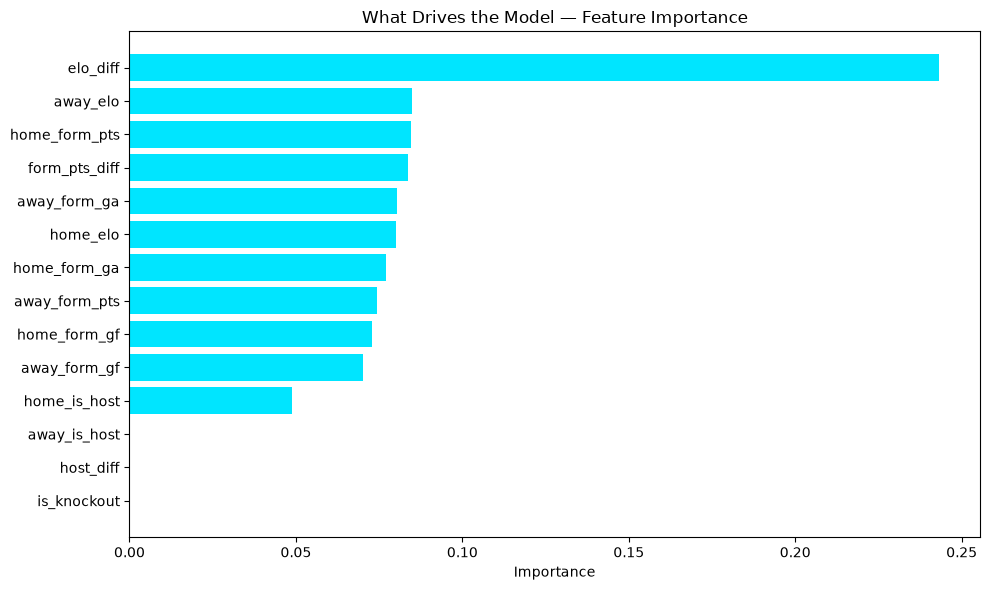

In [13]:
# --- Feature Importance ---
import matplotlib.pyplot as plt

# --- Which features actually drove the model's predictions? ---
importances = xgb_mid.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature importance ranking:")
print(feat_imp.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='#00e5ff')
plt.gca().invert_yaxis()
plt.title('What Drives the Model — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [14]:
# -- Saves the Model --
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump({
    'model': xgb_mid,
    'label_encoder': le,
    'feature_cols': feature_cols,
    'weighting_strength': 0.65,
    'test_accuracy': 0.462
}, 'models/wc2026_xgb_model.pkl')

print("Model saved ✓ → models/wc2026_xgb_model.pkl")

Model saved ✓ → models/wc2026_xgb_model.pkl
